<a href="https://colab.research.google.com/github/Naren219/ai-stuff/blob/main/scaling_laws_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [chinchilla](https://arxiv.org/pdf/2203.15556)!

this notebook tries to emulate the findings of chinchilla compute-optimal scaling laws at a small scale.

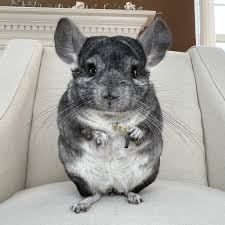

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import math
import matplotlib.pyplot as plt
from itertools import product
from tqdm import tqdm
import numpy as np

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
device.type

'cuda'

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

N = len(train_dataset)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.59MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


In [4]:
perms = {
    seed: torch.randperm(N, generator=torch.Generator().manual_seed(seed))
    for seed in [0, 1, 2]
}

def get_train_loader(factor, seed):
  n = round(N * factor)
  idx = perms[seed][:n].tolist()
  sub_train = Subset(train_dataset, idx)
  g = torch.Generator().manual_seed(seed)
  return DataLoader(sub_train, batch_size=256, shuffle=True, generator=g)

In [5]:
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

In [6]:
image, label = next(iter(test_loader))
print(image.shape)
print(label.shape)

torch.Size([512, 1, 28, 28])
torch.Size([512])


In [7]:
class CNN(nn.Module):
  def __init__(self, width, dropout=0.0):
    super().__init__()
    w1, w2 = width, width * 2
    self.conv1 = nn.Conv2d(1, w1, 3, padding=1)
    self.conv2 = nn.Conv2d(w1, w2, 3, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.fc = nn.Linear(w2*7*7, 10)
    self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.flatten(1)
    x = self.dropout(x)
    x = self.fc(x)
    return x

In [8]:
def flops_per_sample(width):
  w1, w2 = width, width * 2
  flops_conv1 = 2 * 1 * w1 * 28 * 28 * 3 * 3
  flops_conv2 = 2 * w1 * w2 * 14 * 14 * 3 * 3
  flops_fc = 2 * (w2 * 7 * 7) * 10
  return flops_conv1 + flops_conv2 + flops_fc

In [9]:
def width_lr(width, base_width=16, base_lr=1e-3):
    return base_lr * math.sqrt(base_width / width)

In [10]:
def fit(model, lr, train_loader):
  model = model.to(device)
  optim = torch.optim.Adam(model.parameters(), lr=lr)
  loss_fn = nn.CrossEntropyLoss()

  model.train()
  for image, label in train_loader:
    image = image.to(device)
    label = label.to(device)

    optim.zero_grad()
    preds = model(image)
    loss = loss_fn(preds, label)
    loss.backward()
    optim.step()

  val_loss, correct, n = 0.0, 0, 0

  model.eval()
  with torch.no_grad():
    for image, label in test_loader:
      image = image.to(device)
      label = label.to(device)

      preds = model(image)
      loss = loss_fn(preds, label)
      batch_size = image.size(0)
      val_loss += loss.item() * batch_size
      correct += (preds.argmax(1) == label).sum().item()
      n += batch_size

  return val_loss / n, correct / n

In [11]:
widths = [round(16 * math.sqrt(2) ** k) for k in range(7)]
data_idx = [2.0 ** -k for k in range(6)]

In [71]:
results = []
for frac, width in tqdm(product(data_idx, widths), total=len(data_idx) * len(widths)):
  losses, accs = [], []
  n = round(N * frac)
  compute = n * flops_per_sample(width)

  for seed in [0, 1, 2]:
    model = CNN(width=width)
    train_loader = get_train_loader(frac, seed)
    val_loss, val_acc = fit(model, width_lr(width), train_loader)
    losses.append(val_loss)
    accs.append(val_acc)

  results.append({
      "width": width,
      "frac": frac,
      "compute": compute,
      "val_loss": sum(losses) / len(losses),
      "val_acc": sum(accs) / len(accs)
  })

100%|██████████| 42/42 [13:09<00:00, 18.80s/it]


In [12]:
def compute_optimal_loss(results):
  best = {}
  for r in results:
    c = r['compute']
    if c not in best or r['val_loss'] > best[c][0]:
      best[c] = (r['val_loss'], r['width'])
  sorted_c = sorted(best)
  return sorted_c, [best[c][0] for c in sorted_c], [best[c][1] for c in sorted_c]

In [13]:
def fit_power_law(xs, ys):
  log_x = np.log(xs)
  log_y = np.log(ys)
  slope, intercept = np.polyfit(log_x, log_y, deg=1)
  return slope, np.exp(intercept)

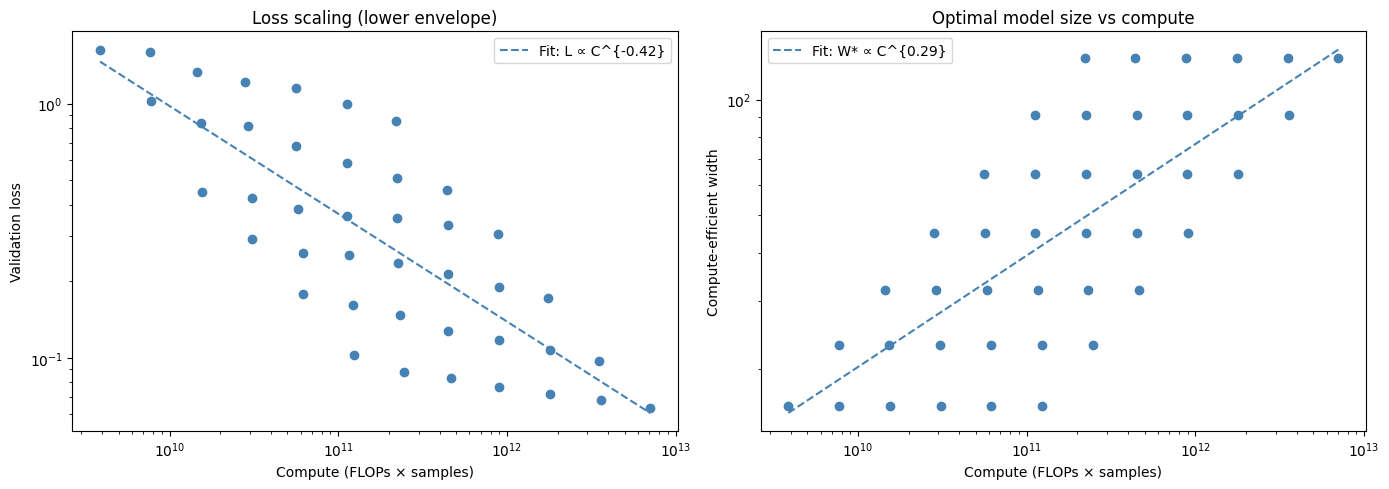

In [75]:
color="steelblue"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
computes, opt_losses, opt_widths = compute_optimal_loss(results)

exp_l, coef_l = fit_power_law(computes, opt_losses)
fit_ys = [coef_l * c**exp_l for c in computes]
axes[0].scatter(computes, opt_losses, color=color, zorder=3)
axes[0].plot(computes, fit_ys, color=color, linestyle="--",
             label=f"Fit: L ∝ C^{{{exp_l:.2f}}}")

exp_w, coef_w = fit_power_law(computes, opt_widths)
fit_ws = [coef_w * c**exp_w for c in computes]

axes[1].scatter(computes, opt_widths, color=color, zorder=3)
axes[1].plot(computes, fit_ws, color=color, linestyle="--",
              label=f"Fit: W* ∝ C^{{{exp_w:.2f}}}")

for ax, ylabel, title in zip(
    axes,
    ["Validation loss", "Compute-efficient width"],
    ["Loss scaling (lower envelope)", "Optimal model size vs compute"]
):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Compute (FLOPs × samples)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

left:
- for every compute budget, the plot shows the lowest acheived validation loss. then a power-law fit was applied.
- vertical bands: there are multiple FLOP/sample combinations that yield the same x value.
- every 10x increase in compute budget cuts loss by a factor of 10^(-0.42)=2.6x.

right:
- for every compute budget, we take the width that resulted in the lowest loss.
- as our compute budget grows, 29% of the log-scaling should go into making the model wider and the rest go towards training steps.
- this result makes sense for MNIST since wider networks stop helping before more training examples.

In [15]:
# from google.colab import drive
# drive.mount('/content/drive')

# import pickle
# with open('drive/MyDrive/dev-files/micro-scaling-laws/results_latest.pkl', 'wb') as f:
#   pickle.dump(results, f)

# with open('drive/MyDrive/dev-files/micro-scaling-laws/results_latest.pkl', 'rb') as f:
#   results = pickle.load(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
